# CatBoost - Walmart Weekly Sales

A third gradient-boosted tree model alongside the LightGBM and XGBoost notebooks, following the
same **global tabular** recipe: one model over all `(Store, Dept)` series, full-dataset scope,
WMAE sample weights (holiday weeks 5x), MAE objective, expanding-window CV for selection, and a
single competition-like holdout for the winner.

**Where it deliberately diverges from the LightGBM/XGBoost notebooks:**

1. **Native categorical handling.** Those notebooks one-hot-encode `Store` (45) + `Dept` (81) +
   `Type` into ~130 sparse columns. CatBoost instead takes them as `cat_features` and encodes
   them with **ordered target statistics** -- high-cardinality encoding without the OHE blow-up
   and without target leakage (that's what CatBoost's ordered boosting buys). We measure this
   directly against an OHE ablation.
2. **Native missing-value handling.** MarkDowns are ~70% missing. Rather than impute them to 0 or
   the median, CatBoost can split on "is missing" natively, so we pass the raw values with NaN
   and let the model decide. Ablated against zero-imputation.

Everything else is kept identical to the other tree notebooks so the full-dataset WMAE is
directly comparable to LightGBM / XGBoost / N-BEATS.


In [1]:
from __future__ import annotations

import time
from copy import deepcopy

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd

from catboost import CatBoostRegressor, Pool

from walmart_forecasting.data import load_merged_data
from walmart_forecasting.experiment import (
    CV_FOLDS,
    CV_VALIDATION_WEEKS,
    DEFAULT_RANDOM_SEED,
    build_common_parameters,
    build_result_row,
    make_run_name,
    save_architecture_result,
)
from walmart_forecasting.features import (
    add_basic_features,
    add_exact_lag_features,
)
from walmart_forecasting.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    weighted_mae,
)
from walmart_forecasting.preprocessing import build_tree_preprocessor
from walmart_forecasting.tracking import mlflow_run
from walmart_forecasting.validation import (
    competition_like_holdout,
    expanding_window_splits,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("Setup complete.")

/Users/chkhai/Documents/uni6/ml/walmart-store-sales-forecasting/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.


## Configuration

In [2]:
ARCHITECTURE = "catboost"
EXPERIMENT_NAME = "CatBoost_Training"

HOLIDAY_WEIGHT = 5.0
NON_HOLIDAY_WEIGHT = 1.0

EARLY_STOPPING_ROUNDS = 100

# CatBoost has no CUDA GPU on Apple Silicon (Metal is unsupported), so this runs on CPU threads.
BASE_PARAMETERS = {
    "iterations": 3000,
    "learning_rate": 0.03,
    "depth": 8,
    "l2_leaf_reg": 3.0,
    "random_strength": 1.0,
    "bagging_temperature": 1.0,
    "border_count": 254,
}

# The three columns the LightGBM/XGBoost notebooks one-hot encode; here they go in natively.
BASE_CATEGORICALS = ["Store", "Dept", "Type"]

## Data loading and validation splits

In [3]:
data = load_merged_data()

train = data.train.copy()
train["Date"] = pd.to_datetime(train["Date"])
test = data.test.copy()
test["Date"] = pd.to_datetime(test["Date"])

series_count = train.groupby(["Store", "Dept"]).ngroups

# Same protocol as the other tree notebooks: horizon inferred from the competition test window,
# expanding-window CV for model selection, and one final holdout for the winner.
holdout_split = competition_like_holdout(train, test)
development = holdout_split.train
holdout_rows = holdout_split.validation

cv_splits = expanding_window_splits(
    development, n_splits=CV_FOLDS, validation_weeks=CV_VALIDATION_WEEKS
)

print(f"Series: {series_count:,} | train rows: {len(train):,}")
print(f"Holdout: {holdout_split.validation_start.date()} -> "
      f"{holdout_split.validation_end.date()} ({holdout_split.validation_weeks} weeks)")
print(f"CV folds: {len(cv_splits)} x {CV_VALIDATION_WEEKS} weeks")

Series: 3,331 | train rows: 421,570
Holdout: 2012-02-03 -> 2012-10-26 (39 weeks)
CV folds: 3 x 13 weeks


## Feature preparation

Two builders sharing the same `add_basic_features` / `add_exact_lag_features` helpers as the
other notebooks:

* `build_native_features` -- returns a DataFrame with `Store/Dept/Type` (and optionally the
  calendar fields) kept as **categorical columns**, plus the list of categorical names to hand to
  CatBoost. MarkDowns are passed raw (NaN preserved) when `markdown_strategy="native"`.
* `build_ohe_matrix` -- the LightGBM/XGBoost path: `prepare_features` + `build_tree_preprocessor`,
  producing a one-hot sparse matrix with no `cat_features`. Used only for the encoding ablation.

In [4]:
MARKDOWN_COLUMNS = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]
ECONOMIC_COLUMNS = ["CPI", "Unemployment"]
CALENDAR_COLUMNS = ["year", "month", "quarter", "week_of_year"]

# Lags around one year back. All >= 39 (the horizon), so every one is known for the entire
# forecast window -- no leakage, unlike short lags which would be mostly-NaN at inference.
YEAR_AGO_LAGS = (50, 51, 52, 53, 54)
YEAR_AGO_AGG_COLUMNS = ["lag_yearago_mean", "lag_yearago_max", "lag_yearago_min"]
HOLIDAY_DISTANCE_COLUMNS = [
    "weeks_to_thanksgiving", "weeks_to_christmas",
    "is_thanksgiving_week", "is_black_friday_week", "is_pre_christmas",
]


def _thanksgiving(year):
    """US Thanksgiving: the 4th Thursday of November."""
    first = pd.Timestamp(int(year), 11, 1)
    days_to_first_thursday = (3 - first.weekday()) % 7  # Thursday == weekday 3
    return first + pd.Timedelta(days=int(days_to_first_thursday) + 21)  # +3 weeks


def _nearest_signed_weeks(dates, holidays):
    """Signed weeks from each date to the NEAREST holiday (positive = holiday still ahead)."""
    hol = np.sort(np.array([np.datetime64(pd.Timestamp(h), "D") for h in holidays]))
    d = pd.to_datetime(dates).values.astype("datetime64[D]")
    pos = np.searchsorted(hol, d)
    left = np.clip(pos - 1, 0, len(hol) - 1)
    right = np.clip(pos, 0, len(hol) - 1)
    dl = (hol[left] - d) / np.timedelta64(1, "D")
    dr = (hol[right] - d) / np.timedelta64(1, "D")
    return np.where(np.abs(dl) <= np.abs(dr), dl, dr) / 7.0


def add_holiday_distance_features(dataframe):
    """Pure-calendar distance-to-holiday features -- known for any future date, zero leakage."""
    result = dataframe.copy()
    dates = pd.to_datetime(result["Date"])
    years = range(int(dates.dt.year.min()) - 1, int(dates.dt.year.max()) + 2)
    christmases = [pd.Timestamp(y, 12, 25) for y in years]
    thanksgivings = [_thanksgiving(y) for y in years]

    weeks_to_thx = np.clip(_nearest_signed_weeks(dates, thanksgivings), -12, 12)
    weeks_to_xmas = np.clip(_nearest_signed_weeks(dates, christmases), -12, 12)
    result["weeks_to_thanksgiving"] = weeks_to_thx
    result["weeks_to_christmas"] = weeks_to_xmas
    # Weekly data is Friday-anchored; flag the weeks that actually carry the spike.
    result["is_thanksgiving_week"] = (np.abs(weeks_to_thx) <= 0.5).astype("int8")
    result["is_black_friday_week"] = ((weeks_to_thx >= -1.0) & (weeks_to_thx <= 0.0)).astype("int8")
    result["is_pre_christmas"] = ((weeks_to_xmas > 0) & (weeks_to_xmas <= 4)).astype("int8")
    return result


def _ordered_with_features(rows, history, lags, holiday_features=False, year_ago_window=False):
    ordered = rows.sort_values(["Date", "Store", "Dept"]).reset_index(drop=True).copy()
    ordered["_row_order"] = np.arange(len(ordered))

    feats = add_basic_features(ordered)
    if holiday_features:
        feats = add_holiday_distance_features(feats)
    if lags:
        feats = add_exact_lag_features(rows=feats, history=history, lags=lags)
        for lag in lags:
            feats[f"lag_{lag}_missing"] = feats[f"lag_{lag}"].isna().astype("int8")

    if year_ago_window:
        # Aggregate the year-ago window so a +/-1 week holiday shift year to year still lines up.
        cols = [f"lag_{lag}" for lag in YEAR_AGO_LAGS if f"lag_{lag}" in feats.columns]
        feats["lag_yearago_mean"] = feats[cols].mean(axis=1)
        feats["lag_yearago_max"] = feats[cols].max(axis=1)
        feats["lag_yearago_min"] = feats[cols].min(axis=1)

    feats = feats.sort_values("_row_order").reset_index(drop=True)
    ordered = ordered.sort_values("_row_order").drop(columns="_row_order").reset_index(drop=True)
    return ordered, feats


def build_native_features(rows, history, lags, markdown_strategy="native",
                          include_economic=True, categorical_calendar=False,
                          holiday_features=False, year_ago_window=False):
    """Feature frame for CatBoost's native categorical path. Returns (ordered_rows, X, cat_cols)."""
    effective_lags = tuple(sorted(set(lags) | (set(YEAR_AGO_LAGS) if year_ago_window else set())))
    ordered, feats = _ordered_with_features(
        rows, history, effective_lags, holiday_features, year_ago_window
    )

    categorical = list(BASE_CATEGORICALS)
    numeric = ["Size", "IsHoliday", "Temperature", "Fuel_Price"]

    if categorical_calendar:
        categorical += CALENDAR_COLUMNS
    else:
        numeric += CALENDAR_COLUMNS

    # MarkDowns: raw values (NaN preserved when native, else zero-filled) PLUS missing indicators.
    markdown_block = feats[MARKDOWN_COLUMNS].copy()
    if markdown_strategy == "zero":
        markdown_block = markdown_block.fillna(0.0)
    elif markdown_strategy != "native":
        raise ValueError("markdown_strategy must be 'native' or 'zero'.")
    numeric += MARKDOWN_COLUMNS + [f"{c}_missing" for c in MARKDOWN_COLUMNS]

    if include_economic:
        numeric += ECONOMIC_COLUMNS + ["CPI_missing", "Unemployment_missing"]

    for lag in effective_lags:
        numeric += [f"lag_{lag}", f"lag_{lag}_missing"]
    if year_ago_window:
        numeric += YEAR_AGO_AGG_COLUMNS
    if holiday_features:
        numeric += HOLIDAY_DISTANCE_COLUMNS

    x = pd.DataFrame(index=feats.index)
    for col in categorical:
        # CatBoost cat_features must be non-null; Store/Dept/Type have no NaN, but cast to str.
        x[col] = feats[col].astype("string").fillna("NA").astype(str)
    for col in numeric:
        source = markdown_block if col in MARKDOWN_COLUMNS else feats
        x[col] = pd.to_numeric(source[col], errors="coerce").astype("float64")

    return ordered, x, categorical


def build_ohe_matrix(rows, history, lags, markdown_strategy, include_economic, preprocessor=None):
    """LightGBM/XGBoost-style one-hot matrix, for the encoding ablation only."""
    ordered, feats = _ordered_with_features(rows, history, lags)
    feats = feats.drop(columns=["Weekly_Sales", "Date"], errors="ignore")

    extra_numeric = []
    for lag in lags:
        extra_numeric += [f"lag_{lag}", f"lag_{lag}_missing"]

    if preprocessor is None:
        preprocessor = build_tree_preprocessor(
            extra_numeric_columns=extra_numeric,
            include_economic=include_economic,
            markdown_strategy=markdown_strategy if markdown_strategy != "native" else "zero",
        )
        matrix = preprocessor.fit_transform(feats)
    else:
        matrix = preprocessor.transform(feats)
    return ordered, matrix, preprocessor

In [5]:
def make_sample_weights(rows):
    return np.where(
        rows["IsHoliday"].astype(bool), HOLIDAY_WEIGHT, NON_HOLIDAY_WEIGHT
    ).astype(float)


def evaluate_predictions(rows, predictions):
    return {
        "wmae": weighted_mae(rows["Weekly_Sales"], predictions, rows["IsHoliday"]),
        "mae": mean_absolute_error(rows["Weekly_Sales"], predictions),
        "rmse": root_mean_squared_error(rows["Weekly_Sales"], predictions),
    }

## Cross-validation trial runner

One trial = one feature/encoding/parameter choice. For each fold we build the features, train a
`CatBoostRegressor` with **weighted MAE early stopping** (via `Pool` weights on the eval set, so
the stopping metric is the WMAE we report), predict the fold's validation block, and pool the
WMAE across folds. `categorical_mode` switches between the native and OHE feature paths.

In [6]:
def _fit_catboost(x_train, y_train, w_train, x_valid, y_valid, w_valid, cat_features, params):
    train_pool = Pool(x_train, y_train, weight=w_train, cat_features=cat_features)
    valid_pool = Pool(x_valid, y_valid, weight=w_valid, cat_features=cat_features)

    model = CatBoostRegressor(
        loss_function="MAE",
        eval_metric="MAE",
        random_seed=DEFAULT_RANDOM_SEED,
        od_type="Iter",
        od_wait=EARLY_STOPPING_ROUNDS,
        thread_count=-1,
        allow_writing_files=False,
        verbose=0,
        **params,
    )
    fit_start = time.perf_counter()
    model.fit(train_pool, eval_set=valid_pool)
    fit_seconds = time.perf_counter() - fit_start
    return model, valid_pool, fit_seconds


def _build_fold(rows, history, trial):
    if trial["categorical_mode"] == "native":
        ordered, x, cat_cols = build_native_features(
            rows, history, trial["lags"],
            markdown_strategy=trial["markdown_strategy"],
            include_economic=trial["include_economic"],
            categorical_calendar=trial.get("categorical_calendar", False),
            holiday_features=trial.get("holiday_features", False),
            year_ago_window=trial.get("year_ago_window", False),
        )
        cat_features = [x.columns.get_loc(c) for c in cat_cols]
        return ordered, x, cat_features
    # OHE ablation path (fit preprocessor on train, reuse on validation via the returned handle)
    ordered, matrix, _ = build_ohe_matrix(
        rows, history, trial["lags"], trial["markdown_strategy"],
        trial["include_economic"], preprocessor=trial.get("_ohe_preprocessor"),
    )
    return ordered, matrix, []


def run_cv_trial(trial, log_mlflow=True):
    fold_results = []

    for fold_number, fold in enumerate(cv_splits, start=1):
        if trial["categorical_mode"] == "ohe":
            # Fit the OHE preprocessor on this fold's training rows, reuse it for validation.
            train_ordered, x_train_m, prep = build_ohe_matrix(
                fold.train, fold.train, trial["lags"], trial["markdown_strategy"],
                trial["include_economic"], preprocessor=None,
            )
            valid_ordered, x_valid_m, _ = build_ohe_matrix(
                fold.validation, fold.train, trial["lags"], trial["markdown_strategy"],
                trial["include_economic"], preprocessor=prep,
            )
            cat_features = []
        else:
            train_ordered, x_train_m, cat_features = _build_fold(fold.train, fold.train, trial)
            valid_ordered, x_valid_m, _ = _build_fold(fold.validation, fold.train, trial)

        y_train = train_ordered["Weekly_Sales"].to_numpy()
        y_valid = valid_ordered["Weekly_Sales"].to_numpy()
        w_train = make_sample_weights(train_ordered)
        w_valid = make_sample_weights(valid_ordered)

        model, valid_pool, fit_seconds = _fit_catboost(
            x_train_m, y_train, w_train, x_valid_m, y_valid, w_valid, cat_features,
            trial["parameters"],
        )

        predict_start = time.perf_counter()
        predictions = model.predict(valid_pool)
        predict_seconds = time.perf_counter() - predict_start

        metrics = evaluate_predictions(valid_ordered, predictions)
        fold_results.append({
            "fold": fold_number, **metrics,
            "best_iteration": int(model.get_best_iteration() or trial["parameters"]["iterations"]),
            "fit_seconds": fit_seconds, "predict_seconds": predict_seconds,
        })
        print(f"{trial['trial_id']} | fold={fold_number} | WMAE={metrics['wmae']:,.2f} | "
              f"best_iter={fold_results[-1]['best_iteration']}")

    fold_frame = pd.DataFrame(fold_results)
    summary = {
        "trial_id": trial["trial_id"], "trial_name": trial["trial_name"],
        "feature_set": trial["feature_set"], "preprocessing": trial["preprocessing"],
        "categorical_mode": trial["categorical_mode"], "lags": str(trial["lags"]),
        "markdown_strategy": trial["markdown_strategy"], "include_economic": trial["include_economic"],
        "cv_wmae_mean": float(fold_frame["wmae"].mean()),
        "cv_wmae_std": float(fold_frame["wmae"].std(ddof=0)),
        "cv_mae_mean": float(fold_frame["mae"].mean()),
        "cv_rmse_mean": float(fold_frame["rmse"].mean()),
        "best_iteration_median": int(np.median(fold_frame["best_iteration"])),
        "fit_seconds": float(fold_frame["fit_seconds"].sum()),
        "predict_seconds": float(fold_frame["predict_seconds"].sum()),
    }
    # Expose per-fold WMAE so the holiday fold (fold 3) is visible, not hidden in the mean.
    for row in fold_results:
        summary[f"fold_{row['fold']}_wmae"] = row["wmae"]

    if log_mlflow:
        run_name = make_run_name(
            architecture=ARCHITECTURE, stage="tuning",
            feature_set=trial["feature_set"], trial_name=trial["trial_name"],
        )
        parameters = build_common_parameters(
            architecture=ARCHITECTURE, stage="tuning", feature_set=trial["feature_set"],
            preprocessing=trial["preprocessing"], evaluation_scope="full_dataset",
            forecast_strategy="global_tabular", series_count=series_count,
            extra_parameters={
                **trial["parameters"], "lags": list(trial["lags"]),
                "categorical_mode": trial["categorical_mode"],
                "markdown_strategy": trial["markdown_strategy"],
                "include_economic": trial["include_economic"],
            },
        )
        logged = {k: summary[k] for k in
                  ["cv_wmae_mean", "cv_wmae_std", "cv_mae_mean", "cv_rmse_mean",
                   "best_iteration_median", "fit_seconds", "predict_seconds"]}
        for row in fold_results:
            logged[f"fold_{row['fold']}_wmae"] = row["wmae"]
        with mlflow_run(
            experiment_name=EXPERIMENT_NAME, run_name=run_name, parameters=parameters,
            tags={"architecture": ARCHITECTURE, "stage": "tuning", "scope": "full_dataset",
                  "trial_id": trial["trial_id"]},
        ):
            mlflow.log_metrics(logged)

    return summary, fold_frame

## Feature trials

Mirror the LightGBM notebook's feature ablations, on the native categorical path:
`core` calendar, then `+lag52`, then dropping the economic regressors.

In [7]:
def make_trial(trial_id, trial_name, feature_set, preprocessing, categorical_mode="native",
               lags=(), markdown_strategy="native", include_economic=True,
               categorical_calendar=False, holiday_features=False, year_ago_window=False,
               parameters=None):
    return {
        "trial_id": trial_id, "trial_name": trial_name, "feature_set": feature_set,
        "preprocessing": preprocessing, "categorical_mode": categorical_mode, "lags": lags,
        "markdown_strategy": markdown_strategy, "include_economic": include_economic,
        "categorical_calendar": categorical_calendar, "holiday_features": holiday_features,
        "year_ago_window": year_ago_window,
        "parameters": deepcopy(parameters or BASE_PARAMETERS),
    }


feature_trials = [
    make_trial("feat_core", "core", "core_calendar_native_v1",
               "catboost_native_markdown_native_economic_raw_v1"),
    make_trial("feat_lag52", "lag52", "core_calendar_lag52_native_v1",
               "catboost_native_markdown_native_economic_raw_v1", lags=(52,)),
    make_trial("feat_lag52_no_econ", "lag52_no_economic", "core_calendar_lag52_no_economic_native_v1",
               "catboost_native_markdown_native_no_economic_v1", lags=(52,), include_economic=False),
]

feature_summaries = []
for trial in feature_trials:
    summary, _ = run_cv_trial(trial)
    feature_summaries.append(summary)

feature_table = pd.DataFrame(feature_summaries).sort_values("cv_wmae_mean")
feature_table[["trial_id", "cv_wmae_mean", "cv_wmae_std", "best_iteration_median", "fit_seconds"]]

feat_core | fold=1 | WMAE=2,828.67 | best_iter=2997
feat_core | fold=2 | WMAE=2,706.28 | best_iter=2998
feat_core | fold=3 | WMAE=4,378.22 | best_iter=2999


Accessing as lchkh23

Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

🏃 View run catboost__tuning__core_calendar_native_v1__core__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/8/runs/4ac4b305a1524d03926fc78a4ae0e8a3
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/8
feat_lag52 | fold=1 | WMAE=1,692.54 | best_iter=2505
feat_lag52 | fold=2 | WMAE=1,663.72 | best_iter=1533
feat_lag52 | fold=3 | WMAE=2,925.72 | best_iter=972


...

🏃 View run catboost__tuning__core_calendar_lag52_native_v1__lag52__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/8/runs/b603f736e3874b0bb554cfa0a03a3b1f
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/8
feat_lag52_no_econ | fold=1 | WMAE=1,703.26 | best_iter=2194
feat_lag52_no_econ | fold=2 | WMAE=1,713.53 | best_iter=1299
feat_lag52_no_econ | fold=3 | WMAE=2,886.62 | best_iter=720


Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

🏃 View run catboost__tuning__core_calendar_lag52_no_economic_native_v1__lag52_no_economic__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/8/runs/5bd5ade4f5e547f08aa07f992765dd67
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/8


,trial_id,cv_wmae_mean,cv_wmae_std,best_iteration_median,fit_seconds
1,feat_lag52,"2,093.9934",588.2357,1533,183.3372
2,feat_lag52_no_econ,"2,101.1349",555.4366,1299,160.9416
0,feat_core,"3,304.3889",760.9557,2998,267.9016


In [8]:
best_feature = min(feature_summaries, key=lambda s: s["cv_wmae_mean"])
best_feature_trial = next(t for t in feature_trials if t["trial_id"] == best_feature["trial_id"])
print(f"Best feature trial: {best_feature['trial_id']} "
      f"(cv_wmae_mean={best_feature['cv_wmae_mean']:,.2f})")

Best feature trial: feat_lag52 (cv_wmae_mean=2,093.99)


## Encoding ablation: native categoricals vs one-hot

The headline CatBoost question. Same features as the best trial above, but encode `Store/Dept/Type`
by one-hot (the LightGBM/XGBoost path) instead of native `cat_features`. If native wins, that is
the concrete justification for using CatBoost here rather than a third OHE tree.

In [9]:
native_ref = deepcopy(best_feature_trial)
native_ref["trial_id"] = "enc_native"
native_ref["trial_name"] = "native_categoricals"

ohe_ablation = deepcopy(best_feature_trial)
ohe_ablation["trial_id"] = "enc_ohe"
ohe_ablation["trial_name"] = "onehot_categoricals"
ohe_ablation["categorical_mode"] = "ohe"
ohe_ablation["feature_set"] = best_feature_trial["feature_set"].replace("native", "ohe")
ohe_ablation["preprocessing"] = "catboost_onehot_markdown_zero_v1"

encoding_summaries = [run_cv_trial(t)[0] for t in (native_ref, ohe_ablation)]
encoding_table = pd.DataFrame(encoding_summaries)
encoding_table[["trial_id", "categorical_mode", "cv_wmae_mean", "cv_wmae_std", "fit_seconds"]]

enc_native | fold=1 | WMAE=1,692.54 | best_iter=2505
enc_native | fold=2 | WMAE=1,663.72 | best_iter=1533
enc_native | fold=3 | WMAE=2,925.72 | best_iter=972


Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

🏃 View run catboost__tuning__core_calendar_lag52_native_v1__native_categoricals__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/8/runs/46b320b73604498fa741f1af72e5bdf3
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/8
enc_ohe | fold=1 | WMAE=1,672.36 | best_iter=1665
enc_ohe | fold=2 | WMAE=1,584.98 | best_iter=2783
enc_ohe | fold=3 | WMAE=2,779.93 | best_iter=992


Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

🏃 View run catboost__tuning__core_calendar_lag52_ohe_v1__onehot_categoricals__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/8/runs/e2c033b27be24283ab343518048b7605
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/8


,trial_id,categorical_mode,cv_wmae_mean,cv_wmae_std,fit_seconds
0,enc_native,native,"2,093.9934",588.2357,193.8421
1,enc_ohe,ohe,"2,012.4227",543.8773,60.2375


## Missing-value ablation: native NaN vs zero-imputed MarkDowns

CatBoost's other native trick. Re-run the best (native-categorical) config with MarkDowns
zero-imputed, to see whether letting CatBoost split on missingness actually helps.

In [10]:
md_native = deepcopy(best_feature_trial)
md_native["trial_id"] = "md_native"
md_native["trial_name"] = "markdown_native_nan"

md_zero = deepcopy(best_feature_trial)
md_zero["trial_id"] = "md_zero"
md_zero["trial_name"] = "markdown_zero_imputed"
md_zero["markdown_strategy"] = "zero"
md_zero["preprocessing"] = best_feature_trial["preprocessing"].replace("markdown_native", "markdown_zero")

markdown_summaries = [run_cv_trial(t)[0] for t in (md_native, md_zero)]
markdown_table = pd.DataFrame(markdown_summaries)
markdown_table[["trial_id", "markdown_strategy", "cv_wmae_mean", "cv_wmae_std"]]

md_native | fold=1 | WMAE=1,692.54 | best_iter=2505
md_native | fold=2 | WMAE=1,663.72 | best_iter=1533
md_native | fold=3 | WMAE=2,925.72 | best_iter=972


Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

🏃 View run catboost__tuning__core_calendar_lag52_native_v1__markdown_native_nan__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/8/runs/72038d0d62ab4efb925005ec138ff721
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/8
md_zero | fold=1 | WMAE=1,779.59 | best_iter=1462
md_zero | fold=2 | WMAE=1,636.26 | best_iter=2474
md_zero | fold=3 | WMAE=2,930.30 | best_iter=697


Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

🏃 View run catboost__tuning__core_calendar_lag52_native_v1__markdown_zero_imputed__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/8/runs/dd216699190343f8a9e90a61dec99336
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/8


,trial_id,markdown_strategy,cv_wmae_mean,cv_wmae_std
0,md_native,native,"2,093.9934",588.2357
1,md_zero,zero,"2,115.3823",579.1969


## Holiday-targeted features

CV error is dominated by the Nov-Jan fold (Thanksgiving / Black Friday / Christmas): sales peak,
holiday weeks are weighted 5x, and the spikes are hard. Two leakage-safe feature groups aimed
squarely at that fold:

* **Year-ago window** -- `lag_51/52/53` plus rolling mean/max/min over ~50-54 weeks back. All are
  >= the 39-week horizon, so every one is *known* across the whole forecast window. This hands the
  model *last year's* holiday spike (and tolerates the +/-1 week the holidays drift year to year).
* **Holiday distance** -- signed `weeks_to_thanksgiving` / `weeks_to_christmas` plus Black-Friday /
  pre-Christmas flags. Pure calendar math, zero leakage, so the model can *ramp toward* the spike
  instead of being surprised by it.

Built on top of the best feature config so far, compared against it, then combined.

In [11]:
holiday_base = deepcopy(best_feature_trial)
holiday_base["markdown_strategy"] = min(
    markdown_summaries, key=lambda s: s["cv_wmae_mean"]
)["markdown_strategy"]

holiday_experiments = []
for trial_id, name, flags in [
    ("hol_baseline", "baseline_no_holiday_feats", {}),
    ("hol_yearago", "year_ago_window", {"year_ago_window": True}),
    ("hol_distance", "holiday_distance", {"holiday_features": True}),
    ("hol_both", "yearago_plus_distance", {"year_ago_window": True, "holiday_features": True}),
]:
    trial = deepcopy(holiday_base)
    trial["trial_id"] = trial_id
    trial["trial_name"] = name
    trial["feature_set"] = f"catboost_{name}_v1"
    trial.update(flags)
    holiday_experiments.append(run_cv_trial(trial)[0])

holiday_table = pd.DataFrame(holiday_experiments)
# fold_3 is the holiday fold -- the whole point of these features is to shrink it.
holiday_table[["trial_id", "cv_wmae_mean", "cv_wmae_std", "fold_1_wmae", "fold_2_wmae", "fold_3_wmae"]]

hol_baseline | fold=1 | WMAE=1,692.54 | best_iter=2505
hol_baseline | fold=2 | WMAE=1,663.72 | best_iter=1533
hol_baseline | fold=3 | WMAE=2,925.72 | best_iter=972


Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

🏃 View run catboost__tuning__catboost_baseline_no_holiday_feats_v1__baseline_no_holiday_feats__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/8/runs/8b2f0eb02c3848648a463ebda2bf37e6
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/8
hol_yearago | fold=1 | WMAE=1,641.04 | best_iter=2998
hol_yearago | fold=2 | WMAE=1,713.69 | best_iter=1574
hol_yearago | fold=3 | WMAE=3,004.39 | best_iter=1278


Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

...

hol_both | fold=3 | WMAE=2,985.87 | best_iter=1284


Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

🏃 View run catboost__tuning__catboost_yearago_plus_distance_v1__yearago_plus_distance__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/8/runs/3602fa6c163044039eb1755f1f6ebc2d
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/8


,trial_id,cv_wmae_mean,cv_wmae_std,fold_1_wmae,fold_2_wmae,fold_3_wmae
0,hol_baseline,"2,093.9934",588.2357,"1,692.5411","1,663.7213","2,925.7178"
1,hol_yearago,"2,119.7080",626.2697,"1,641.0409","1,713.6897","3,004.3934"
2,hol_distance,"2,108.1281",602.5750,"1,692.1457","1,672.0200","2,960.2187"
3,hol_both,"2,131.9457",603.9684,"1,688.3259","1,721.6417","2,985.8694"


In [12]:
holiday_best = min(holiday_experiments, key=lambda s: s["cv_wmae_mean"])
holiday_best_flags = {
    "hol_baseline": {}, "hol_yearago": {"year_ago_window": True},
    "hol_distance": {"holiday_features": True},
    "hol_both": {"year_ago_window": True, "holiday_features": True},
}[holiday_best["trial_id"]]
print(f"Best holiday config: {holiday_best['trial_id']} "
      f"(cv_wmae_mean={holiday_best['cv_wmae_mean']:,.2f}) vs "
      f"baseline {holiday_experiments[0]['cv_wmae_mean']:,.2f}")

Best holiday config: hol_baseline (cv_wmae_mean=2,093.99) vs baseline 2,093.99


## Hyperparameter tuning

Starting from the best feature/encoding/missing/holiday config, a small grid over the CatBoost
knobs that matter most here: tree `depth`, `l2_leaf_reg` (regularization), and `learning_rate`.

In [13]:
winning_config = deepcopy(holiday_base)  # native path, best features + markdown winner
winning_config.update(holiday_best_flags)  # + the winning holiday-feature group

parameter_variants = {
    "depth6": {"depth": 6},
    "depth10": {"depth": 10},
    "l2_reg6": {"l2_leaf_reg": 6.0},
    "lr05": {"learning_rate": 0.05},
}

param_summaries = []
for name, overrides in parameter_variants.items():
    trial = deepcopy(winning_config)
    trial["trial_id"] = f"param_{name}"
    trial["trial_name"] = name
    trial["parameters"].update(overrides)
    param_summaries.append(run_cv_trial(trial)[0])

# include the untuned baseline for comparison
baseline_summary = run_cv_trial({**deepcopy(winning_config),
                                 "trial_id": "param_base", "trial_name": "base"})[0]
param_summaries.append(baseline_summary)
param_table = pd.DataFrame(param_summaries).sort_values("cv_wmae_mean")
param_table[["trial_id", "cv_wmae_mean", "cv_wmae_std", "best_iteration_median"]]

param_depth6 | fold=1 | WMAE=1,750.63 | best_iter=2728
param_depth6 | fold=2 | WMAE=1,681.37 | best_iter=2976
param_depth6 | fold=3 | WMAE=2,936.43 | best_iter=1029


Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

🏃 View run catboost__tuning__core_calendar_lag52_native_v1__depth6__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/8/runs/51a6fc375b9b49fbac39006a3fc12df0
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/8
param_depth10 | fold=1 | WMAE=1,674.11 | best_iter=1976
param_depth10 | fold=2 | WMAE=1,694.35 | best_iter=1265
param_depth10 | fold=3 | WMAE=2,955.54 | best_iter=600


Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

...

🏃 View run catboost__tuning__core_calendar_lag52_native_v1__lr05__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/8/runs/924e3a06a2eb41a1ad3c4590ec84a92f
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/8
param_base | fold=1 | WMAE=1,692.54 | best_iter=2505
param_base | fold=2 | WMAE=1,663.72 | best_iter=1533
param_base | fold=3 | WMAE=2,925.72 | best_iter=972


Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

🏃 View run catboost__tuning__core_calendar_lag52_native_v1__base__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/8/runs/270f966f931c49dbaed27b76d3021109
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/8


,trial_id,cv_wmae_mean,cv_wmae_std,best_iteration_median
3,param_lr05,"2,092.4922",598.4656,1126
4,param_base,"2,093.9934",588.2357,1533
2,param_l2_reg6,"2,098.3518",585.4320,1438
1,param_depth10,"2,108.0017",599.3597,1265
0,param_depth6,"2,122.8108",576.0079,2728


In [14]:
best_param = min(param_summaries, key=lambda s: s["cv_wmae_mean"])
best_variant = best_param["trial_id"].replace("param_", "")

final_config = deepcopy(winning_config)
if best_variant in parameter_variants:
    final_config["parameters"].update(parameter_variants[best_variant])
print(f"Best parameter variant: {best_param['trial_id']} "
      f"(cv_wmae_mean={best_param['cv_wmae_mean']:,.2f})")
final_config["parameters"]

Best parameter variant: param_lr05 (cv_wmae_mean=2,092.49)


{'iterations': 3000,
 'learning_rate': 0.05,
 'depth': 8,
 'l2_leaf_reg': 3.0,
 'random_strength': 1.0,
 'bagging_temperature': 1.0,
 'border_count': 254}

## Final model - train on all development data, holdout evaluated once

Retrain the winning config on everything before the holdout window, using the median best
iteration from CV (early stopping needs a validation set we no longer hold out), and score the
untouched holdout a single time.

In [15]:
final_iterations = int(np.median([s["best_iteration_median"] for s in param_summaries]))
final_config["parameters"]["iterations"] = max(final_iterations, 100)

_feature_kwargs = dict(
    markdown_strategy=final_config["markdown_strategy"],
    include_economic=final_config["include_economic"],
    holiday_features=final_config.get("holiday_features", False),
    year_ago_window=final_config.get("year_ago_window", False),
)
dev_rows, x_dev, cat_features = build_native_features(
    development, development, final_config["lags"], **_feature_kwargs
)
holdout_ordered, x_holdout, _ = build_native_features(
    holdout_rows, development, final_config["lags"], **_feature_kwargs
)

dev_pool = Pool(x_dev, dev_rows["Weekly_Sales"].to_numpy(),
                weight=make_sample_weights(dev_rows), cat_features=cat_features)

final_model = CatBoostRegressor(
    loss_function="MAE", eval_metric="MAE", random_seed=DEFAULT_RANDOM_SEED,
    thread_count=-1, allow_writing_files=False, verbose=0, **final_config["parameters"],
)
fit_start = time.perf_counter()
final_model.fit(dev_pool)
final_fit_seconds = time.perf_counter() - fit_start

predict_start = time.perf_counter()
holdout_predictions = final_model.predict(x_holdout)
final_predict_seconds = time.perf_counter() - predict_start

final_metrics = evaluate_predictions(holdout_ordered, holdout_predictions)
print("Holdout metrics (evaluated once):")
for k, v in final_metrics.items():
    print(f"  {k}: {v:,.2f}")

Holdout metrics (evaluated once):
  wmae: 1,722.69
  mae: 1,723.39
  rmse: 3,684.54


## Feature importance

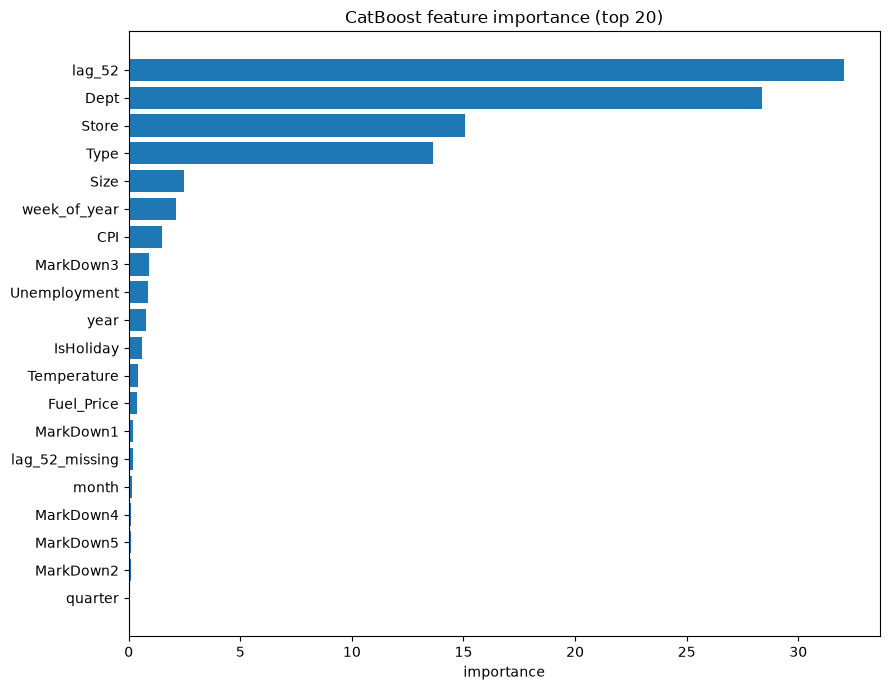

,feature,importance
0,lag_52,32.0587
1,Dept,28.3677
2,Store,15.0805
3,Type,13.6260
4,Size,2.4981
5,week_of_year,2.1102
6,CPI,1.5121
7,MarkDown3,0.9230
8,Unemployment,0.8646
9,year,0.7727


In [16]:
importances = final_model.get_feature_importance(dev_pool)
importance_frame = (
    pd.DataFrame({"feature": x_dev.columns, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

top = importance_frame.head(20)[::-1]
plt.figure(figsize=(9, 7))
plt.barh(top["feature"], top["importance"])
plt.title("CatBoost feature importance (top 20)")
plt.xlabel("importance")
plt.tight_layout()
plt.show()
importance_frame.head(15)

## Final MLflow logging + save result

Logs the holdout metrics **and the fitted model artifact in the same run**, so the model and the
numbers that describe it live together (the LightGBM notebook does the equivalent with its sklearn
pipeline). The model is logged with an inferred signature + input example, then reloaded and
checked to reproduce the same predictions -- proof the artifact is actually usable.

In [17]:
import mlflow.catboost
from mlflow.models import infer_signature

final_run_name = make_run_name(
    architecture=ARCHITECTURE, stage="final",
    feature_set=final_config["feature_set"], trial_name="final",
)
final_params = build_common_parameters(
    architecture=ARCHITECTURE, stage="final", feature_set=final_config["feature_set"],
    preprocessing=final_config["preprocessing"], evaluation_scope="full_dataset",
    forecast_strategy="global_tabular", series_count=series_count,
    extra_parameters={
        **final_config["parameters"], "lags": list(final_config["lags"]),
        "categorical_mode": final_config["categorical_mode"],
        "markdown_strategy": final_config["markdown_strategy"],
        "include_economic": final_config["include_economic"],
        "holiday_features": final_config.get("holiday_features", False),
        "year_ago_window": final_config.get("year_ago_window", False),
        "cat_features": BASE_CATEGORICALS,
    },
)

# Native model consumes the feature frame directly, so the signature/example use x_holdout as-is.
signature = infer_signature(x_holdout, holdout_predictions)
input_example = x_holdout.head(5)

with mlflow_run(
    experiment_name=EXPERIMENT_NAME, run_name=final_run_name, parameters=final_params,
    tags={"architecture": ARCHITECTURE, "stage": "final", "scope": "full_dataset"},
) as run:
    mlflow.log_metrics({
        "holdout_wmae": final_metrics["wmae"], "holdout_mae": final_metrics["mae"],
        "holdout_rmse": final_metrics["rmse"], "fit_seconds": final_fit_seconds,
        "predict_seconds": final_predict_seconds,
    })
    # Model artifact in the SAME run as its metrics.
    model_info = mlflow.catboost.log_model(
        final_model, artifact_path="model",
        signature=signature, input_example=input_example,
    )
    print(f"Logged model artifact to: {model_info.model_uri}")

# Reload and confirm the artifact reproduces the in-memory model's predictions exactly.
loaded_model = mlflow.catboost.load_model(model_info.model_uri)
np.testing.assert_allclose(
    loaded_model.predict(x_holdout.head(100)), holdout_predictions[:100], rtol=1e-6
)
print("Reloaded-model prediction check passed -- artifact is usable.")

final_cv = min(param_summaries, key=lambda s: s["cv_wmae_mean"])
result_row = build_result_row(
    architecture=ARCHITECTURE, run_name=final_run_name, stage="final", tracker="mlflow",
    feature_set=final_config["feature_set"], preprocessing=final_config["preprocessing"],
    evaluation_scope="full_dataset", forecast_strategy="global_tabular", series_count=series_count,
    metrics={
        "cv_wmae_mean": final_cv["cv_wmae_mean"], "cv_wmae_std": final_cv["cv_wmae_std"],
        "holdout_wmae": final_metrics["wmae"], "holdout_mae": final_metrics["mae"],
        "holdout_rmse": final_metrics["rmse"],
    },
    fit_seconds=final_fit_seconds, predict_seconds=final_predict_seconds,
    notes=(
        "CatBoost, global tabular. Native cat_features for Store/Dept/Type (vs OHE in the "
        "LightGBM/XGBoost notebooks) and native-NaN markdowns, both ablated. Config selected by "
        "mean CV WMAE; holdout evaluated once."
    ),
)
save_architecture_result(result_row)
pd.DataFrame([result_row])

Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

2026/07/11 19:50:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged model artifact to: models:/m-998b6be847a04b6a9b9bf7e4bbe90aa8
🏃 View run catboost__final__core_calendar_lag52_native_v1__final__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/8/runs/107d84d9bd204362979b93e7e7f553b5
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/8


Reloaded-model prediction check passed -- artifact is usable.


,architecture,run_name,stage,tracker,feature_set,preprocessing,validation_id,data_version,evaluation_scope,forecast_strategy,series_count,random_seed,cv_wmae_mean,cv_wmae_std,holdout_wmae,holdout_mae,holdout_rmse,fit_seconds,predict_seconds,notes
0,catboost,catboost__final__core_calendar_lag52_native_v1...,final,mlflow,core_calendar_lag52_native_v1,catboost_native_markdown_native_economic_raw_v1,expanding_3x13_holdout_39_v1,processed_v1,full_dataset,global_tabular,3331,42,"2,092.4922",598.4656,"1,722.6928","1,723.3868","3,684.5429",78.9827,0.1903,"CatBoost, global tabular. Native cat_features ..."


## Takeaways

* **CatBoost vs the other trees.** `holdout_wmae` here is directly comparable to
  `lightgbm_final.csv` / `xgboost_final.csv` -- same full-dataset scope, same WMAE, same
  global-tabular framing.
* **Native categoricals vs OHE** (encoding ablation): the concrete reason to reach for CatBoost
  rather than a third one-hot tree. Report the gap.
* **Native-NaN markdowns vs zero-imputation** (missing-value ablation): whether letting the model
  split on missingness beats imputing.
* **No GPU:** CatBoost's GPU backend is CUDA-only, so this ran on CPU threads on Apple Silicon --
  fine for this dataset size.
